# Tuning revisited — why tuned configurations lose out of sample, and what actually helps

`pairs_trading_04_hyperparameter_tuning_yahoo.ipynb` tuned eight hyperparameters on one pair and found that the
winner did worse than nb02's hand-set defaults on the 2026 hold-out. This notebook asks *why*, and tests
the candidate fixes — the Kalman fit, the hedge model, the z-score look-back rule, the training window,
the tuning objective and the pair set — under a protocol that can actually tell them apart.

**Protocol (nested, portfolio-level).**

* A **portfolio of 40 pairs**: the 29 dual-gate pairs that involve neither of the two network hubs, CCL
  and NCLH (see `visualize_cointegrated_pairs_yahoo.ipynb`, where those two alone account for 250 of the
  279 significant pairs), plus the 11 members of nb02's 15-pair shortlist not already among them.
  Aggregating across pairs at equal capital ($10k each) is what gives enough trades to distinguish
  procedures; a single pair cannot.
* **Walk-forward folds** on 2020–2025 (train 504 / test 126 / step 63 bars); each fold contributes the
  bars before the next refit, so every bar from 2022 on has exactly one out-of-fold return per
  (pair, model, configuration), from a model fitted strictly before it.
* **Tune period** = out-of-fold bars in 2022–2024: configurations are *chosen* here.
* **Validation period** = out-of-fold bars in 2025: procedures are *compared* here.
* **Hold-out** = 2026 (174 bars to mid-September): each model is refit on the trailing 504 bars of 2025
  (756 for the two long-window variants), and the hold-out is evaluated **once**, at the end, for every
  procedure at the same time.

The 2026 window is never used to choose anything. Iterating on it "until the tuned model looks good"
would only produce another in-sample number.

## 0. Setup

In [1]:
from pathlib import Path
import sys, time, warnings, pickle

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from joblib import Parallel, delayed

import pairs
from pairs import load_prices, load_universe, find_cointegrated_pairs_dualgate
from pairs.models.kalman import _kalman_dynamic_hedge, filter_kf_on_new
from pairs.strategies.signals import generate_pair_signals, estimate_halflife_window
from pairs.strategies.evaluate import evaluate_pair_signals
from pairs.validation import walk_forward_splits

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
N_JOBS = -1
TEST_BARS, STEP_BARS = 126, 63
TRAIN_START, TRAIN_END = "2020-01-01", "2025-12-31"
VALID_START, HOLDOUT_START, HOLDOUT_END = "2025-01-01", "2026-01-01", "2026-09-12"
CAP = 10_000
EVAL_KW = dict(cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252, capital_base=CAP)
MIN_TRADES = 8                                    # a configuration must trade at least this often in the tune period
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})
print("pairs", pairs.__version__)

pairs 0.1.0


## 1. The machinery

Three hedge models, each producing per-fold frames with `P1, P2, beta, resid` on the test window plus the
z-score look-back and warm-up history from the training window (the look-ahead fix of nb02):

* **Kalman** (`pairs.models.kalman`): EM iterations and transition noise `q` as the levers; the fit is
  causal (filtered states), and the test window is continued from the end-of-training state.
* **OLS static**: a fixed hedge fitted on the training window, held through the test window.
* **OLS rolling**: a trailing-window hedge refit every day from past data only.

The z-score look-back is normally the half-life of the model's own training residual; one variant takes
it from the *static* spread instead, because the Kalman residual's half-life is a filter artefact
(`tv_cointegration_kalman_yahoo.ipynb`).

In [2]:
def _ols_fit(df):
    y, x = df["P1"].to_numpy(float), df["P2"].to_numpy(float)
    X = np.column_stack([np.ones_like(x), x]); a, b = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(a), float(b)

def _static_resid(df, a, b):
    return pd.Series(df["P1"].to_numpy(float) - a - b * df["P2"].to_numpy(float), index=df.index, name="resid")

def fold_frame(df_train, df_test, model):
    kind = model["kind"]
    if kind == "kalman":
        _, _, states, params = _kalman_dynamic_hedge("P1", "P2", df_train, q=model["q"], em_iters=model["em"],
                                                     mode="filter", return_params=True)
        if states is None or params is None: return None
        frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
        st_te, _ = filter_kf_on_new(df_test["P1"], df_test["P2"], frozen=frozen,
                                    last_state=(params["last_state_mean"], params["last_state_cov"]), mode="filter")
        frame = df_test[["P1", "P2"]].join(st_te[["beta", "resid"]], how="inner"); hist = states["resid"]
    elif kind == "ols":
        a, b = _ols_fit(df_train)
        frame = df_test[["P1", "P2"]].copy(); frame["beta"] = b; frame["resid"] = _static_resid(df_test, a, b)
        hist = _static_resid(df_train, a, b)
    elif kind == "ols_roll":
        w = model["window"]
        full = pd.concat([df_train[["P1", "P2"]], df_test[["P1", "P2"]]])
        c = full["P1"].rolling(w).cov(full["P2"]).shift(1); v = full["P2"].rolling(w).var().shift(1)
        beta = c / v; alpha = full["P1"].rolling(w).mean().shift(1) - beta * full["P2"].rolling(w).mean().shift(1)
        resid = full["P1"] - alpha - beta * full["P2"]
        frame = df_test[["P1", "P2"]].copy(); frame["beta"] = beta.loc[df_test.index]; frame["resid"] = resid.loc[df_test.index]
        frame = frame.dropna(); hist = resid.loc[df_train.index].dropna()
    else:
        raise ValueError(kind)
    if len(frame) < 30: return None
    if model.get("zwin", "model") == "static":
        a, b = _ols_fit(df_train); z_window = estimate_halflife_window(_static_resid(df_train, a, b))
    else:
        z_window = estimate_halflife_window(hist)
    return {"frame": frame, "z_window": int(z_window), "z_history": hist}

def fold_frames_for(dfp, splits, model):
    warnings.filterwarnings("ignore")
    return [None if len(tr) < 60 else fold_frame(dfp.loc[tr], dfp.loc[te], model) for tr, te in splits]

def oof_pnl(frames, scfg, n_folds):
    parts, trades = [], 0
    for k, f in enumerate(frames):
        if f is None: continue
        sig = generate_pair_signals(f["frame"], capital_per_pair=CAP, z_window=f["z_window"], z_history=f["z_history"], **scfg)
        daily, _, summ = evaluate_pair_signals(f["frame"][["P1", "P2"]], sig, **EVAL_KW)
        if k < n_folds - 1: daily = daily.iloc[:STEP_BARS]
        parts.append(daily["pnl_net"]); trades += int(summ["n_trades"])
    if not parts: return None, 0
    s = pd.concat(parts); return s[~s.index.duplicated(keep="first")].sort_index(), trades

def holdout_pnl(df_train_tail, df_hold, model, scfg):
    warnings.filterwarnings("ignore")
    f = fold_frame(df_train_tail, df_hold, model)
    if f is None: return None, 0
    sig = generate_pair_signals(f["frame"], capital_per_pair=CAP, z_window=f["z_window"], z_history=f["z_history"], **scfg)
    daily, _, summ = evaluate_pair_signals(f["frame"][["P1", "P2"]], sig, **EVAL_KW)
    return daily["pnl_net"], int(summ["n_trades"])

def sharpe(pnl, cap=CAP, periods=252):
    r = pnl / cap
    return float(r.mean() / r.std(ddof=0) * np.sqrt(periods)) if len(r) > 1 and r.std(ddof=0) > 0 else np.nan

def portfolio(series_by_pair):
    # Equal-capital portfolio: sum of per-pair pnl on the union of dates; Sharpe on n_pairs * CAP.
    df = pd.DataFrame(series_by_pair).fillna(0.0); tot = df.sum(axis=1)
    r = tot / (df.shape[1] * CAP)
    return tot, (float(r.mean() / r.std(ddof=0) * np.sqrt(252)) if r.std(ddof=0) > 0 else np.nan)

def signal_grid(full):
    if full:
        return [dict(z_method=m, z_entry=e, z_exit=x, z_stop=s, max_hold_bars=h, cooldown_bars=c)
                for m in ("robust", "rolling") for e in (1.5, 2.0, 2.5, 3.0) for x in (0.0, 0.5, 1.0)
                for s in (3.5, 4.0, 5.0) for h in (None, 60) for c in (0, 5)]
    return [dict(z_method="robust", z_entry=e, z_exit=x, z_stop=4.0, max_hold_bars=None, cooldown_bars=0)
            for e in (1.5, 2.0, 2.5, 3.0) for x in (0.0, 0.5, 1.0)]

DEFAULT_SIG = dict(z_method="robust", z_entry=2.0, z_exit=0.5, z_stop=4.0, max_hold_bars=None, cooldown_bars=0)
K0_NAME = "K em5 q1e-5 (default)"
MODELS = {
    K0_NAME:        dict(kind="kalman", em=5, q=1e-5),                  # nb02's Kalman
    "K em5 q1e-6":  dict(kind="kalman", em=5, q=1e-6),
    "K em5 q1e-4":  dict(kind="kalman", em=5, q=1e-4),
    "K em0 q1e-6":  dict(kind="kalman", em=0, q=1e-6),
    "K em0 q1e-5":  dict(kind="kalman", em=0, q=1e-5),
    "K em0 q1e-4":  dict(kind="kalman", em=0, q=1e-4),
    "K em0 q1e-3":  dict(kind="kalman", em=0, q=1e-3),
    "K default, z-window from static spread": dict(kind="kalman", em=5, q=1e-5, zwin="static"),
    "OLS static per fold":  dict(kind="ols"),
    "OLS rolling 252":      dict(kind="ols_roll", window=252),
    "OLS rolling 126":      dict(kind="ols_roll", window=126),
}
# Full 288-configuration grid only for nb02's model at the standard window; a 12-point grid
# (z_entry × z_exit, everything else at default) for every other model / window.
def grid_for(name, train_bars): return signal_grid(full=(name == K0_NAME and train_bars == 504))
BLOCKS = [(name, 504) for name in MODELS] + [(K0_NAME, 252), ("OLS static per fold", 252), (K0_NAME, 756), ("OLS static per fold", 756)]

## 2. Data and the pair set

Prices and the dual-gate screen for the combined S&P 500 + Nasdaq-100 universe come from the caches of
`visualize_cointegrated_pairs_yahoo.ipynb` (recomputed here if absent). The hold-out prices are downloaded once.

In [3]:
# nb02's §3.4 shortlist, pinned. Regenerate from pairs_trading_02_yahoo.ipynb §3.4 if that notebook is
# re-run: the composite score behind it depends on nb02's Kalman states, so it moves when nb02 does.
NB02_SHORTLIST = [("BKNG","MA"),("AVGO","RL"),("NCLH","REG"),("HSIC","PLD"),("NCLH","ZBH"),("BA","JKHY"),
                  ("CRM","EQIX"),("NCLH","SBAC"),("NCLH","VRSN"),("NCLH","WEC"),("NCLH","SJM"),("NCLH","WTW"),
                  ("NCLH","PNW"),("NCLH","SPG"),("NCLH","NTRS")]

px_file, sc_file = CACHE / "viz_prices_spx_ndx_combined.parquet", CACHE / "viz_screen_spx_ndx_combined.parquet"
if px_file.exists() and sc_file.exists():
    df_all = pd.read_parquet(px_file); screen = pd.read_parquet(sc_file)
else:
    df_all, _ = load_prices("openbb", load_universe("spx_ndx_combined"), TRAIN_START, TRAIN_END, return_failed=True, show_progress=False)
    df_all.to_parquet(px_file)
    dt = df_all.index.get_level_values("datetime"); g = df_all.groupby(level="ticker")
    keep = g.apply(lambda x: x.index.get_level_values("datetime").min()).eq(dt.min()) & g.apply(lambda x: x.index.get_level_values("datetime").max()).eq(dt.max())
    screen = find_cointegrated_pairs_dualgate(df_all.loc[pd.IndexSlice[keep[keep].index, :]], fdr_method="bh", chunksize=32, show_progress=True)
    screen.to_parquet(sc_file)

px = df_all["close"].unstack("ticker")
sig_pairs = set(screen.index[screen["verdict"] == "pass"])
non_hub = sorted(p for p in sig_pairs if "NCLH" not in p and "CCL" not in p)
pairs_all = non_hub + [p for p in NB02_SHORTLIST if p not in non_hub]
hub = [p for p in pairs_all if p not in non_hub]
tickers = sorted({t for p in pairs_all for t in p})

hold_file = CACHE / "study_holdout_prices.parquet"
if hold_file.exists():
    hold = pd.read_parquet(hold_file)
else:
    dfh, failed = load_prices("openbb", tickers, HOLDOUT_START, HOLDOUT_END, return_failed=True, show_progress=False)
    assert not failed, failed
    hold = dfh["close"].unstack("ticker"); hold.to_parquet(hold_file)
px, hold = px[tickers], hold[tickers]
print(f"{len(pairs_all)} pairs: {len(non_hub)} non-hub dual-gate pairs + {len(hub)} from nb02's shortlist ({len(tickers)} tickers)")
print(f"training window {px.index[0].date()} → {px.index[-1].date()} ({len(px)} bars); hold-out {hold.index[0].date()} → {hold.index[-1].date()} ({len(hold)} bars)")

40 pairs: 29 non-hub dual-gate pairs + 11 from nb02's shortlist (60 tickers)
training window 2020-01-02 → 2025-12-31 (1508 bars); hold-out 2026-01-02 → 2026-09-11 (174 bars)


## 3. Out-of-fold returns for every (pair, model, configuration)

Stored compactly (one float32 matrix of configurations × bars per pair) and cached, because the cold
computation is about eight minutes on 16 cores.

In [4]:
OOF_CACHE = CACHE / "tuning_study_oof.pkl"

def _compute_block(name, train_bars):
    model, grid = MODELS[name], grid_for(name, train_bars)
    def run(pair):
        dfp = px[list(pair)].rename(columns={pair[0]: "P1", pair[1]: "P2"}).dropna()
        splits = walk_forward_splits(dfp.index, train_bars=train_bars, test_bars=TEST_BARS, step_bars=STEP_BARS)
        frames = fold_frames_for(dfp, splits, model)
        return pair, [oof_pnl(frames, scfg, len(splits)) for scfg in grid]
    res = Parallel(n_jobs=N_JOBS, batch_size=1)(delayed(run)(p) for p in pairs_all)
    dates = pd.DatetimeIndex(sorted({d for _, out in res for s, _ in out if s is not None for d in s.index}))
    pos = {d: i for i, d in enumerate(dates)}
    pnl, trades = {}, {}
    for pair, out in res:
        arr = np.full((len(grid), len(dates)), np.nan, dtype=np.float32); tr = np.zeros(len(grid), dtype=np.int32)
        for i, (s, t) in enumerate(out):
            if s is None: continue
            arr[i, [pos[d] for d in s.index]] = s.to_numpy(np.float32); tr[i] = t
        pnl[pair], trades[pair] = arr, tr
    return {"grid": grid, "dates": dates, "pnl": pnl, "trades": trades}

if OOF_CACHE.exists():
    study = pickle.load(open(OOF_CACHE, "rb"))
    assert study["pairs"] == pairs_all, "cached study was built for a different pair set — delete the cache"
    blocks = study["blocks"]
    print(f"loaded {len(blocks)} cached blocks from {OOF_CACHE}")
else:
    t0 = time.time(); blocks = {}
    for name, tb in BLOCKS:
        blocks[(name, tb)] = _compute_block(name, tb)
        print(f"  {name:42s} train {tb}: {len(blocks[(name, tb)]['grid']):3d} configs × {len(pairs_all)} pairs   ({time.time() - t0:.0f}s)")
    pickle.dump({"pairs": pairs_all, "non_hub": non_hub, "blocks": blocks}, open(OOF_CACHE, "wb"), protocol=5)

loaded 15 cached blocks from cache/tuning_study_oof.pkl


## 4. Tuning procedures, compared on the validation year

For every (model, window) block, four procedures pick a configuration per pair on the **tune** period and
are scored on the **validation** period as a portfolio:

* **default** — nb02's thresholds, no tuning;
* **per-pair tuned** — nb04's procedure: each pair takes its own best configuration;
* **pooled tuned** — one configuration for all pairs, chosen by the portfolio's tune-period Sharpe;
* **oracle** — the configuration that is best *on validation itself*: not a procedure anyone can run,
  but a reference for how much a tuner leaves on the table. Read it as a reference and not a strict
  bound: the oracle and the pooled pick are both chosen on the pairs clearing `MIN_TRADES` and then
  reported over all 40, so a tuned row can occasionally print above its own oracle — `OLS static per
  fold | train 504` shows per-pair tuned at 1.49 against an oracle of 0.94.

In [5]:
def cfg_index(grid, cfg): return next(i for i, g in enumerate(grid) if g == cfg)

def series(block, pair, i, period):
    # pnl Series of configuration i for `pair`, restricted to 'tune' / 'valid' / 'all'
    s = pd.Series(block["pnl"][pair][i], index=block["dates"]).dropna()
    if period == "tune":  return s[s.index < VALID_START]
    if period == "valid": return s[s.index >= VALID_START]
    return s

def analyse(block, pairs=None):
    pairs = pairs or pairs_all
    grid = block["grid"]; d_idx = cfg_index(grid, DEFAULT_SIG)
    n_cfg = len(grid)
    # per-pair tuned
    chosen_pp = {}
    for p in pairs:
        best, best_s = d_idx, -np.inf
        for i in range(n_cfg):
            if block["trades"][p][i] < MIN_TRADES: continue
            sh = sharpe(series(block, p, i, "tune"))
            if np.isfinite(sh) and sh > best_s: best, best_s = i, sh
        chosen_pp[p] = best
    # pooled tuned (portfolio Sharpe on the tune period) and oracle (on validation)
    def best_pooled(period):
        best, best_s = d_idx, -np.inf
        for i in range(n_cfg):
            ser = {p: series(block, p, i, period) for p in pairs if block["trades"][p][i] >= MIN_TRADES}
            if len(ser) < max(3, len(pairs) // 2): continue
            _, sh = portfolio(ser)
            if np.isfinite(sh) and sh > best_s: best, best_s = i, sh
        return best
    chosen_pool, oracle = best_pooled("tune"), best_pooled("valid")
    procs = {"default": {p: d_idx for p in pairs}, "per-pair tuned": chosen_pp,
             "pooled tuned": {p: chosen_pool for p in pairs}, "oracle (peeks at validation)": {p: oracle for p in pairs}}
    rows = {}
    for name, idx in procs.items():
        vser = {p: series(block, p, idx[p], "valid") for p in pairs}
        tser = {p: series(block, p, idx[p], "tune") for p in pairs}
        tot, sh = portfolio(vser); _, sh_t = portfolio(tser)
        rows[name] = {"tune Sharpe": sh_t if name != "oracle (peeks at validation)" else np.nan,
                      "valid Sharpe": sh, "valid P&L ($k)": tot.sum() / 1e3,
                      "pairs +": f"{int(sum(s.sum() > 0 for s in vser.values()))}/{len(pairs)}",
                      "median pair Sharpe": float(np.nanmedian([sharpe(s) for s in vser.values()]))}
    return pd.DataFrame(rows).T, {"per_pair": chosen_pp, "pooled": chosen_pool, "default": d_idx, "grid": grid}

tables, choices = {}, {}
for key, block in blocks.items():
    tables[key], choices[key] = analyse(block)
valid_tab = pd.concat({f"{n} | train {tb}": t for (n, tb), t in tables.items()}, names=["model | window", "procedure"])
valid_tab.style.format({"tune Sharpe": "{:.2f}", "valid Sharpe": "{:.2f}", "valid P&L ($k)": "{:.1f}", "median pair Sharpe": "{:.2f}"}) \
    .background_gradient(subset=["valid Sharpe"], cmap="RdYlGn", vmin=-1, vmax=2.5)

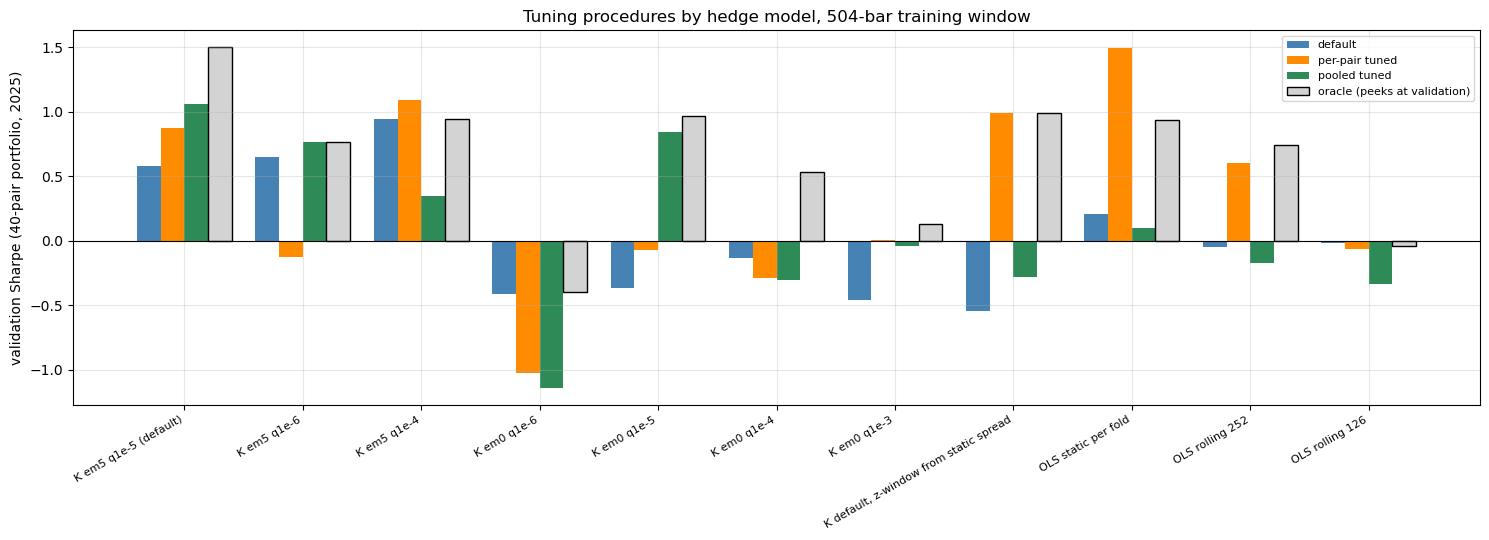

In [6]:
sub = valid_tab.xs("valid Sharpe", axis=1).unstack("procedure").loc[[f"{n} | train 504" for n in MODELS]]
sub.columns.name = None
fig, ax = plt.subplots(figsize=(15, 5.5))
x = np.arange(len(sub)); w = 0.2
for k, (proc, color) in enumerate((("default", "steelblue"), ("per-pair tuned", "darkorange"), ("pooled tuned", "seagreen"), ("oracle (peeks at validation)", "lightgrey"))):
    ax.bar(x + (k - 1.5) * w, sub[proc], width=w, label=proc, color=color, edgecolor="black" if proc.startswith("oracle") else None)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([i.replace(" | train 504", "") for i in sub.index], rotation=30, ha="right", fontsize=8)
ax.set_ylabel(f"validation Sharpe ({len(pairs_all)}-pair portfolio, 2025)"); ax.legend(fontsize=8)
ax.set_title("Tuning procedures by hedge model, 504-bar training window")
plt.tight_layout(); plt.show()

**Reading.** Three things stand out.

1. **Tuning nb02's model helps on validation.** With the default Kalman (EM, `q=1e-5`, train 504) both
   procedures beat the hand-set thresholds: pooled tuning 1.06 and per-pair 0.88 against a default of
   0.58, with per-pair lifting profitable pairs from 23 of 40 to 29. The oracle that peeks at validation
   reaches 1.50, so a good deal is still left on the table. The warning sign is the "tune Sharpe" column:
   the default scores −0.65 over 2022–2024 and +0.58 in 2025, so the two periods disagree in sign even
   for the configuration nobody chose, and §5 measures how little the first tells you about the second.
2. **The static hedge is the least stable model, in both directions.** OLS refit per fold (train 504)
   posts 1.10 on the tune period but only 0.21 on validation with default thresholds; per-pair tuning
   rescues it to 1.49 while pooled tuning does not (0.10). §5 shows why none of this should be trusted:
   for this model the rank correlation between tune period and validation is *negative*. §7 then has it
   finishing first on the hold-out. Best of the eleven models on the tune period, mid-table on
   validation, best again in 2026: a ranking that swings that far between adjacent years is telling you
   about the years, not the model.
3. **Kalman noise and window length move the needle in validation** — `q=1e-4` (0.94) and `q=1e-6` (0.65)
   both beat `q=1e-5` (0.58), and a 756-bar window (1.01) beats 504 (0.58) and 252 (0.18) — but with no
   monotone pattern in `q`, which is itself a warning that these differences are noisy.

Whether any of this survives the hold-out is the question of §7.

## 5. How much does the tune period tell you about the next year?

Every configuration's portfolio Sharpe on the tune period against its Sharpe on validation, for three
models. A tuner can only work if the cloud slopes upward.

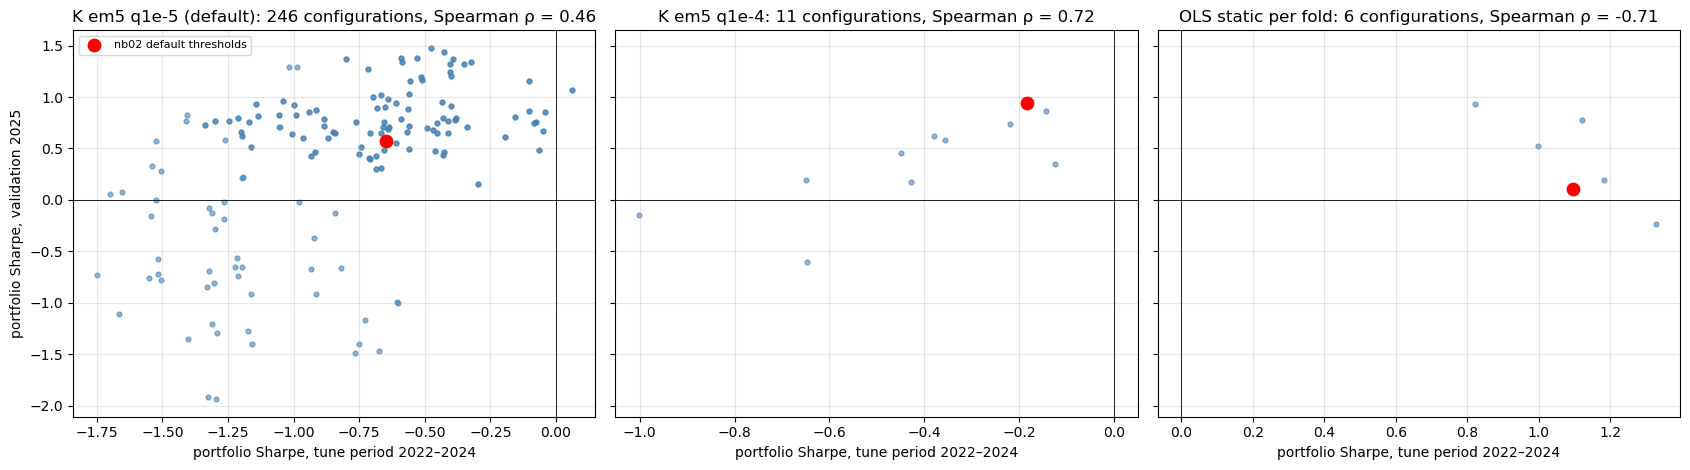

Spearman ρ, tune period vs validation year: {'K em5 q1e-5 (default)': 0.46, 'K em5 q1e-4': 0.72, 'OLS static per fold': -0.71}


In [7]:
RHOS = {}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, name in zip(axes, [K0_NAME, "K em5 q1e-4", "OLS static per fold"]):
    block = blocks[(name, 504)]; grid = block["grid"]; d_idx = cfg_index(grid, DEFAULT_SIG)
    pts = []
    for i in range(len(grid)):
        ser_t = {p: series(block, p, i, "tune") for p in pairs_all if block["trades"][p][i] >= MIN_TRADES}
        ser_v = {p: series(block, p, i, "valid") for p in pairs_all if block["trades"][p][i] >= MIN_TRADES}
        if len(ser_t) < len(pairs_all) // 2: continue
        pts.append((portfolio(ser_t)[1], portfolio(ser_v)[1], i == d_idx))
    pts = pd.DataFrame(pts, columns=["tune", "valid", "is_default"]).dropna()
    rho = spearmanr(pts["tune"], pts["valid"]).correlation
    RHOS[name] = float(rho)
    ax.scatter(pts["tune"], pts["valid"], s=12, alpha=0.6, color="steelblue")
    d = pts[pts["is_default"]]; ax.scatter(d["tune"], d["valid"], s=80, color="red", zorder=3, label="nb02 default thresholds")
    ax.axhline(0, color="black", lw=0.6); ax.axvline(0, color="black", lw=0.6)
    ax.set_title(f"{name}: {len(pts)} configurations, Spearman ρ = {rho:.2f}")
    ax.set_xlabel("portfolio Sharpe, tune period 2022–2024")
axes[0].set_ylabel("portfolio Sharpe, validation 2025"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Spearman ρ, tune period vs validation year:",
      {k: round(v, 2) for k, v in RHOS.items()})

The three models do not behave alike. For nb02's Kalman the rank correlation between the tune period and
validation is ρ = 0.46, and for `q=1e-4` it is 0.72 — positive, but carried largely by the gap between
configurations that fail in *both* periods (those that exit only at the mean) and everything else. Inside
the cluster of sensible configurations the slope is much flatter, so a tuner choosing among them is
choosing mostly noise.

The static hedge is the exception, and it points the wrong way: **ρ = −0.71**, over the six
configurations of its grid that clear the trade minimum on enough pairs to be plotted. The
configurations that did best over 2022–2024 are systematically the ones that did worst in 2025. Six
points is thin evidence and the correlation is not significant on its own, but the sign matters for how
§4 should be read: the static hedge's tuned validation scores were selected fairly, on tune-period
information alone, yet the period they were selected on carries no usable signal about the next one.

## 6. Two adjustments to the tuning itself, and the pair set

**Robust objectives.** Instead of the configuration with the best tune-period Sharpe, choose the one with
the best *worst year* (2022, 2023 or 2024), or average the P&L of the top-5 configurations (an ensemble).
Both are a-priori sensible ways to avoid a single lucky year.

**Hub vs non-hub pairs.** nb02's shortlist is dominated by NCLH — 10 of its 15 members pair against it —
so the "hub" group here is those 10 plus HSIC/PLD; the 29 non-hub pairs are
the ones with pair-specific relationships. If tuning "works" only on the hub pairs, it is fitting the
COVID recovery, not a strategy.

In [8]:
def year_sharpes(ser_by_pair):
    tot, _ = portfolio(ser_by_pair)
    return {y: sharpe(tot[tot.index.year == y], cap=len(ser_by_pair) * CAP) for y in (2022, 2023, 2024)}

rows = []
for name in [K0_NAME, "K em5 q1e-4", "K em5 q1e-6", "OLS static per fold", "OLS rolling 252", "K default, z-window from static spread"]:
    block = blocks[(name, 504)]; grid = block["grid"]; d_idx = cfg_index(grid, DEFAULT_SIG)
    tune, valid = {}, {}
    for i in range(len(grid)):
        ok = [p for p in pairs_all if block["trades"][p][i] >= MIN_TRADES]
        if len(ok) < len(pairs_all) // 2: continue
        tune[i] = {p: series(block, p, i, "tune") for p in ok}; valid[i] = {p: series(block, p, i, "valid") for p in ok}
    mean_s = {i: portfolio(t)[1] for i, t in tune.items()}
    worst = {i: min(year_sharpes(t).values()) for i, t in tune.items()}
    i_mean, i_worst = max(mean_s, key=mean_s.get), max(worst, key=worst.get)
    top5 = sorted(mean_s, key=mean_s.get, reverse=True)[:5]
    ens = {p: pd.concat([valid[i][p] for i in top5 if p in valid[i]], axis=1).fillna(0.0).mean(axis=1)
           for p in pairs_all if any(p in valid[i] for i in top5)}
    rows.append({"model": name, "default": portfolio(valid[d_idx])[1], "argmax mean Sharpe": portfolio(valid[i_mean])[1],
                 "argmax worst-year Sharpe": portfolio(valid[i_worst])[1], "top-5 ensemble": portfolio(ens)[1],
                 "worst-year choice": f"entry {grid[i_worst]['z_entry']}, exit {grid[i_worst]['z_exit']}"})
robust_tab = pd.DataFrame(rows).set_index("model")
robust_tab.style.format({c: "{:.2f}" for c in robust_tab.columns if c != "worst-year choice"}).set_caption("Validation Sharpe by tuning objective (pooled, one configuration for all pairs)")

,default,argmax mean Sharpe,argmax worst-year Sharpe,top-5 ensemble,worst-year choice
model,,,,,
K em5 q1e-5 (default),0.58,1.07,0.49,0.91,"entry 3.0, exit 0.5"
K em5 q1e-4,0.94,0.35,0.73,0.76,"entry 3.0, exit 0.5"
K em5 q1e-6,0.65,0.94,0.94,0.66,"entry 3.0, exit 0.5"
OLS static per fold,0.10,-0.24,0.77,0.45,"entry 1.5, exit 0.5"
OLS rolling 252,-0.05,-0.20,0.24,-0.10,"entry 3.0, exit 1.0"
"K default, z-window from static spread",-0.54,-0.28,-0.43,-0.47,"entry 2.5, exit 1.0"


In [9]:
rows = []
for name, proc in [(K0_NAME, "default"), (K0_NAME, "pooled"), ("K em5 q1e-4", "default"), ("K em5 q1e-4", "per_pair"),
                   ("OLS static per fold", "default"), ("OLS static per fold", "pooled"), ("OLS rolling 252", "pooled"),
                   ("K default, z-window from static spread", "per_pair")]:
    block, ch = blocks[(name, 504)], choices[(name, 504)]
    idx = ch["per_pair"] if proc == "per_pair" else {p: ch[proc] for p in pairs_all}
    row = {"model": name, "procedure": proc.replace("_", "-")}
    for grp, gname in ((hub, "hub pairs"), (non_hub, "non-hub pairs")):
        _, sh = portfolio({p: series(block, p, idx[p], "valid") for p in grp}); row[f"valid {gname}"] = sh
    rows.append(row)
split_tab = pd.DataFrame(rows).set_index(["model", "procedure"])
split_tab.style.format("{:.2f}").background_gradient(cmap="RdYlGn", vmin=-1.5, vmax=2.5).set_caption("Validation Sharpe, hub pairs vs non-hub pairs")

**Reading.** For nb02's model the plain argmax is the best of the objectives here (1.07 against a 0.58
default), with the ensemble close behind (0.91) and the *robust* worst-year objective the worst of the
three (0.49) — the opposite of what a winner's-curse story predicts, and a reminder that with one
validation year these orderings are themselves noisy. Robustness does earn its keep for the static hedge,
whose 0.10 default is beaten by the worst-year objective (0.77) and the ensemble (0.45) while the plain
argmax is negative (−0.24). The worst-year objective almost always picks a *wider* entry (3.0). (The "default"
column of the objectives table is computed on the pairs where the default trades at least `MIN_TRADES`
times, so it can differ from §4.)

The hub split is more telling. With default thresholds the static hedge's validation edge is entirely
hub-driven — 0.65 on the hub pairs against 0.04 on the rest — and nb02's Kalman leans the same way,
though less steeply (0.59 hub, 0.28 non-hub, and 0.89 / 0.40 pooled-tuned). Two procedures go the other
way: rolling-252 pooled tuning is −1.20 on the hubs against 0.58 elsewhere, and the z-window-from-static
variant's per-pair edge is wholly non-hub (2.05 against −0.87). Whenever a procedure's edge lives on one
side of this split, it is a bet on the regime rather than on the strategy.

## 7. The hold-out, touched once

Every procedure in §4 (33 of them, at the 504-bar window) plus the 756-bar Kalman variants, refit on the
trailing 504 (or 756) bars of 2025 and run causally through 2026. Two questions: does the validation
ranking predict the hold-out ranking, and is anything distinguishable from zero?

In [10]:
def run_hold(label, model, pair, cfg, train_bars=504):
    dfp = px[list(pair)].rename(columns={pair[0]: "P1", pair[1]: "P2"}).dropna().iloc[-train_bars:]
    dfh = hold[list(pair)].rename(columns={pair[0]: "P1", pair[1]: "P2"}).dropna()
    s, tr = holdout_pnl(dfp, dfh, model, cfg)
    return label, pair, s, tr

plans = []
for (name, tb), ch in choices.items():
    if tb not in (504, 756) or (tb == 756 and name != K0_NAME): continue
    grid = ch["grid"]; suffix = "" if tb == 504 else " (train 756)"
    plans.append((f"{name}{suffix} | default", MODELS[name], {p: grid[ch["default"]] for p in pairs_all}, tb))
    plans.append((f"{name}{suffix} | pooled tuned", MODELS[name], {p: grid[ch["pooled"]] for p in pairs_all}, tb))
    if tb == 504:
        plans.append((f"{name} | per-pair tuned", MODELS[name], {p: grid[ch["per_pair"][p]] for p in pairs_all}, tb))
t0 = time.time()
res = Parallel(n_jobs=N_JOBS)(delayed(run_hold)(lbl, model, p, cfgs[p], tb) for lbl, model, cfgs, tb in plans for p in pairs_all)
print(f"{len(res)} hold-out evaluations in {time.time() - t0:.0f}s")

hold_series = {}; hold_trades = {}
for lbl, pair, s, tr in res:
    if s is not None and len(s): hold_series.setdefault(lbl, {})[pair] = s
    hold_trades[lbl] = hold_trades.get(lbl, 0) + tr
rows = {}
for lbl, ser in hold_series.items():
    tot, sh = portfolio(ser)
    _, sh_hub = portfolio({p: s for p, s in ser.items() if p in hub}); _, sh_nh = portfolio({p: s for p, s in ser.items() if p in non_hub})
    rows[lbl] = {"hold-out Sharpe": sh, "hold-out P&L ($k)": tot.sum() / 1e3, "trades": hold_trades[lbl],
                 "pairs +": f"{int(sum(s.sum() > 0 for s in ser.values()))}/{len(ser)}", "hub pairs": sh_hub, "non-hub pairs": sh_nh}
hold_tab = pd.DataFrame(rows).T.sort_values("hold-out Sharpe", ascending=False)
se = 1 / np.sqrt(len(hold) / 252)
print(f"Hold-out is {len(hold)} bars: the standard error of an annualised Sharpe measured on it is ≈ {se:.2f}, "
      f"so anything with |Sharpe| < {2 * se:.1f} is indistinguishable from zero.")
hold_tab.style.format({"hold-out Sharpe": "{:.2f}", "hold-out P&L ($k)": "{:.1f}", "hub pairs": "{:.2f}", "non-hub pairs": "{:.2f}"}) \
    .background_gradient(subset=["hold-out Sharpe"], cmap="RdYlGn", vmin=-2, vmax=2)

1400 hold-out evaluations in 21s
Hold-out is 174 bars: the standard error of an annualised Sharpe measured on it is ≈ 1.20, so anything with |Sharpe| < 2.4 is indistinguishable from zero.


,hold-out Sharpe,hold-out P&L ($k),trades,pairs +,hub pairs,non-hub pairs
OLS static per fold | default,1.72,10.7,74,25/40,2.06,0.93
OLS static per fold | pooled tuned,1.69,7.4,52,21/40,1.92,1.17
K em0 q1e-4 | per-pair tuned,1.66,10.9,247,26/40,0.72,1.65
K em5 q1e-5 (default) | pooled tuned,1.40,3.3,59,26/40,0.50,1.53
K em5 q1e-4 | per-pair tuned,1.32,9.9,307,26/40,0.46,1.66
K em5 q1e-5 (default) | per-pair tuned,1.31,8.1,168,24/40,0.78,0.83
K em0 q1e-4 | pooled tuned,1.14,4.9,100,25/40,0.49,1.38
OLS static per fold | per-pair tuned,1.05,6.8,69,22/40,1.83,0.15
K em0 q1e-5 | per-pair tuned,0.98,6.0,192,24/40,0.52,0.93
K em0 q1e-4 | default,0.96,10.1,375,24/40,1.30,-0.47


validation vs hold-out over 33 procedures: Spearman ρ = 0.28, sign agreement 52%


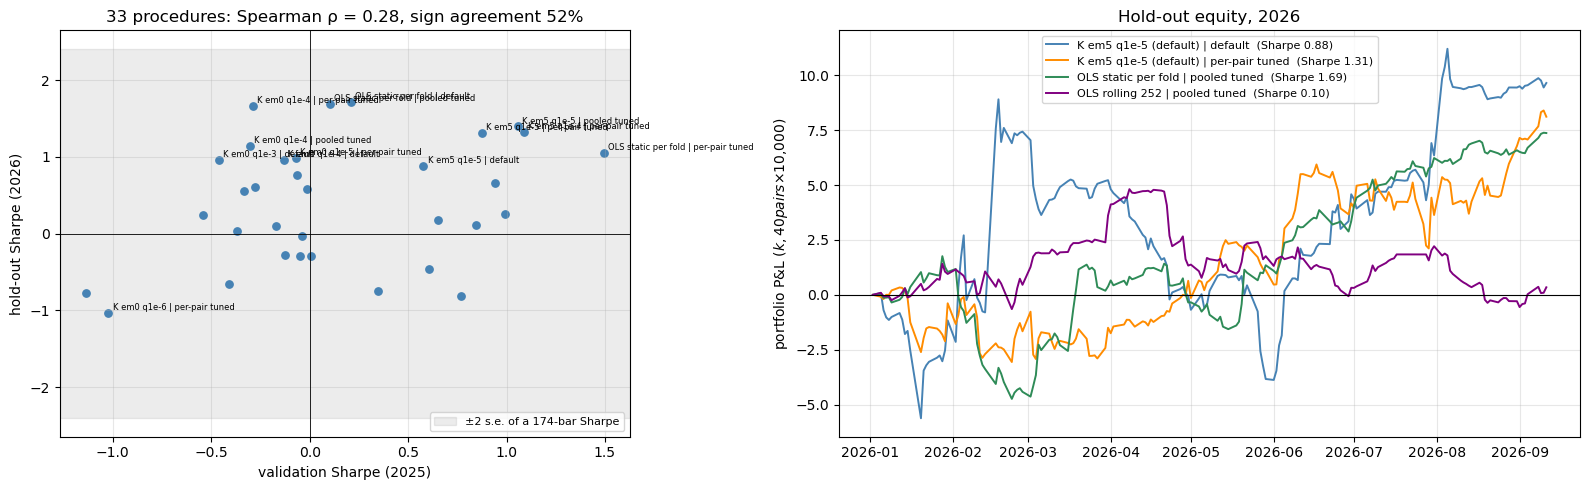

In [11]:
v = valid_tab.xs("valid Sharpe", axis=1)
v.index = [f"{m.replace(' | train 504', '')} | {p}" for m, p in v.index]
j = pd.DataFrame({"valid": v}).join(hold_tab[["hold-out Sharpe"]], how="inner")
j = j[~j.index.str.contains("oracle|train 756")]
rho = spearmanr(j["valid"], j["hold-out Sharpe"]).correlation
agree = (np.sign(j["valid"]) == np.sign(j["hold-out Sharpe"])).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1.3]})
ax = axes[0]
ax.axhspan(-2 * se, 2 * se, color="grey", alpha=0.15, label=f"±2 s.e. of a {len(hold)}-bar Sharpe")
ax.scatter(j["valid"], j["hold-out Sharpe"], s=28, color="steelblue")
for lbl, row in j.iterrows():
    if abs(row["hold-out Sharpe"]) > 0.9 or row["valid"] > 1.8 or "default) | default" in lbl:
        ax.annotate(lbl.replace(" (default)", ""), (row["valid"], row["hold-out Sharpe"]), fontsize=6, xytext=(3, 2), textcoords="offset points")
ax.axhline(0, color="black", lw=0.6); ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("validation Sharpe (2025)"); ax.set_ylabel("hold-out Sharpe (2026)")
ax.set_title(f"{len(j)} procedures: Spearman ρ = {rho:.2f}, sign agreement {agree:.0%}"); ax.legend(fontsize=8, loc="lower right")
print(f"validation vs hold-out over {len(j)} procedures: Spearman ρ = {rho:.2f}, sign agreement {agree:.0%}")
ax = axes[1]
for lbl, color in ((f"{K0_NAME} | default", "steelblue"), (f"{K0_NAME} | per-pair tuned", "darkorange"),
                   ("OLS static per fold | pooled tuned", "seagreen"), ("OLS rolling 252 | pooled tuned", "purple")):
    tot, sh = portfolio(hold_series[lbl]); ax.plot(tot.index, tot.cumsum() / 1e3, color=color, lw=1.4, label=f"{lbl}  (Sharpe {sh:.2f})")
ax.axhline(0, color="black", lw=0.8); ax.set_ylabel(f"portfolio P&L ($k, {len(pairs_all)} pairs × ${CAP:,.0f})"); ax.set_title("Hold-out equity, 2026"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading.** The validation ranking carries a little information about the hold-out this time, but not
much: ρ = 0.28 across 33 procedures, with sign agreement of 52% — a coin flip. The grey band says why an
honest reading stops there: an annualised Sharpe measured on 174 bars carries a standard error of about
1.2, so every procedure in the table sits inside the noise. The top three on validation do survive —
static per-pair tuned (1.49 in 2025) at 1.05, `q=1e-4` per-pair tuned (1.09) at 1.32 and nb02's Kalman
pooled-tuned (1.06) at 1.40 — but the best hold-out score of all, 1.72, belongs to the **static hedge
with default thresholds**, which managed only 0.21 on validation and whose tune period anti-predicts it
(§5). Its hub-pair figure is 2.06, so it is again riding the hub regime, this time in the right
direction. nb02's untuned Kalman comes 13th of 35 at 0.88, against a table median of 0.58. Nothing here
can be called "good out-of-sample performance" with a straight face, and nothing can be called bad
either; the window is too short to know.

## 8. Answers

**Why do tuned configurations underperform?** On this evidence, largely they don't — which is itself the
answer. nb04 saw one pair lose after tuning; across 40 pairs both procedures beat the hand-set defaults on
validation for nb02's model (pooled 1.06 and per-pair 0.88 against 0.58, §4), and the validation leaders
hold up on the hold-out (§7). "Tuning always hurts" was an artifact of a single pair and a single window.

What does *not* hold up is the link a tuner depends on. For nb02's Kalman the tune-to-validation rank
correlation is 0.46 and is carried by the obviously broken configurations; for the static hedge it is
−0.71, actively misleading (§5). Validation to hold-out is ρ = 0.28 with coin-flip sign agreement (§7).
So when tuning wins it is mostly a lucky draw, and the same machinery that produced a win here produced a
loss in nb04. The sharpest illustration is the static hedge: best of the models on the tune period,
mid-table on validation with default thresholds (0.21), first on the hold-out (1.72), with a tune period
that anti-predicts validation throughout.

The hand-set defaults are not smarter; they are simply not selected, so they carry no optimism bias and no
selection penalty either. That does not make them safe: on the hold-out the twelve default rows span ranks
1 to 31 and include both the best procedure in the table and one of the worst (`K em0 q1e-6`, −0.65). Not
being tuned protects you from the winner's curse, not from the model being wrong.

**Do we need to change how the Kalman filter is fitted?** Not on this evidence. EM on beats EM off with
default thresholds; the noise level `q` matters in validation but non-monotonically, and no setting is
distinguishable on the hold-out. The one fitting change with a clear *diagnostic* justification — a
static hedge, since the σ_η tests found no moving coefficient — is the most volatile thing in the study:
0.21 on validation, 1.72 on the hold-out, ρ = −0.71 between its own tune period and validation, and a
hub-pair figure of 0.65 in 2025 against 2.06 in 2026. Whatever it is measuring, one year of it does not
predict the next, and its edge sits on the hub pairs in both.

**What about the training window?** Longer helps the Kalman model in validation with default thresholds
(1.01 at 756 against 0.58 at 504 and 0.18 at 252) but not detectably on the hold-out, and the ordering
reverses once the thresholds are tuned. It is a second-order lever.

**Adjustments that are worth making**, in order:

1. **Tune at the portfolio level with a restricted grid.** A robust objective (worst year, or an
   ensemble of the top few) cuts the winner's curse and costs nothing, but neither is reliably better
   here: for nb02's Kalman the ensemble beats the defaults (0.91 against 0.58) while the worst-year
   objective does not (0.49), and for the static hedge the ordering is the other way round (0.77 against
   0.45). With one validation year these orderings are noise.
2. **Fix the pair set before tuning anything, and report how sensitive the answer is to it.** This
   notebook's own history is the argument: rebuilt on nb02's corrected shortlist the portfolio went from
   44 pairs to 40, the hub group lost its CCL half, and the static hedge went from *worst* procedure on
   the hold-out to *best*. Nothing about the tuning machinery changed. Separate hub pairs from
   pair-specific ones, and read any procedure whose edge sits on one side of that split as a regime bet.
3. **Consider the static hedge where the σ_η test does not reject**, but treat its results on hub pairs
   as regime bets.
4. **Stop expecting a 174-bar hold-out to settle anything.** The honest deliverable of tuning is a
   configuration that is *not worse* than defaults across pairs and years, evaluated on a portfolio; the
   evidence for "better" needs years of hold-out or many more independent pairs.

**Caveats.** One asset universe and one 2020–2025 window; three hedge models and a 12-point grid for the
variants; equal-capital aggregation ignores cross-pair correlation, which is high for the hub pairs;
costs are the pipeline's fixed assumptions. The pair set is pinned to nb02's shortlist as of a particular
run of that notebook, and §8 shows the conclusions move when it changes — treat every ranking here as
conditional on these 40 pairs.